#Importing And Cleaning Dataframe

In [1]:
import gdown
import pandas as pd
import numpy as np
import math
from scipy import stats
from scipy.stats import anderson
import os


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.initializers import HeNormal, GlorotNormal,HeUniform


from tensorflow import keras
import joblib
import json

In [2]:
!pip install gdown -q
import gdown

file_id = "1Rf_RoQHJAliJp92hv6c3m27eAs0f2xmd"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "customer_churn_with_outliers.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Rf_RoQHJAliJp92hv6c3m27eAs0f2xmd
To: /content/customer_churn_with_outliers.csv
100%|██████████| 30.4M/30.4M [00:00<00:00, 117MB/s]


'customer_churn_with_outliers.csv'

In [3]:
df = pd.read_csv("customer_churn_with_outliers.csv")
# df = df.sample(n=400000, random_state=42).reset_index(drop=True)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
df.shape

(442154, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442154 entries, 0 to 442153
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         442154 non-null  float64
 1   Age                435522 non-null  float64
 2   Gender             437732 non-null  object 
 3   Tenure             442154 non-null  float64
 4   Usage Frequency    442154 non-null  float64
 5   Support Calls      433311 non-null  float64
 6   Payment Delay      435522 non-null  float64
 7   Subscription Type  437732 non-null  object 
 8   Contract Length    442154 non-null  object 
 9   Total Spend        437732 non-null  float64
 10  Last Interaction   442154 non-null  float64
 11  Churn              442154 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.5+ MB


In [6]:
df.isnull().sum()

,0
CustomerID,0
Age,6632
Gender,4422
Tenure,0
Usage Frequency,0
Support Calls,8843
Payment Delay,6632
Subscription Type,4422
Contract Length,0
Total Spend,4422


In [7]:
columns_with_missing = df.columns[df.isna().any()].tolist()
columns_with_missing

['Age',
 'Gender',
 'Support Calls',
 'Payment Delay',
 'Subscription Type',
 'Total Spend']

In [8]:
for col in columns_with_missing:
    col_mode = df[col].mode()
    print(f"Mode of column '{col}': {col_mode[0]}")
    if not col_mode.empty:
        df[col] = df[col].fillna(col_mode[0])


Mode of column 'Age': 50.0
Mode of column 'Gender': Male
Mode of column 'Support Calls': 0.0
Mode of column 'Payment Delay': 12.0
Mode of column 'Subscription Type': Standard
Mode of column 'Total Spend': 432.0


In [9]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [10]:
df.drop("CustomerID",axis=1, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442154 entries, 0 to 442153
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                442154 non-null  float64
 1   Gender             442154 non-null  object 
 2   Tenure             442154 non-null  float64
 3   Usage Frequency    442154 non-null  float64
 4   Support Calls      442154 non-null  float64
 5   Payment Delay      442154 non-null  float64
 6   Subscription Type  442154 non-null  object 
 7   Contract Length    442154 non-null  object 
 8   Total Spend        442154 non-null  float64
 9   Last Interaction   442154 non-null  float64
 10  Churn              442154 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.1+ MB


In [12]:
df.duplicated().sum()

np.int64(1107)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
list_of_numeric_column = df.select_dtypes(include=['int64', 'float64']).columns

In [16]:
list_of_numeric_column

Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

## Checking P-Value With Anderson

In [17]:
list_of_distributed_col = []
list_of_not_distributed_col = []

for col in list_of_numeric_column:
    result = anderson(df[col], dist='norm')

    statistic = result.statistic

    critical_value = result.critical_values[
        list(result.significance_level).index(5.0)
    ]

    if statistic <= critical_value:
        list_of_distributed_col.append(col)

        print(
            f"Kolom {col} berdistribusi normal "
            f"(statistic={statistic:.3f}, critical={critical_value:.3f})"
        )
    else:
        list_of_not_distributed_col.append(col)

        print(
            f"Kolom {col} tidak berdistribusi normal "
            f"(statistic={statistic:.3f}, critical={critical_value:.3f})"
        )

Kolom Age tidak berdistribusi normal (statistic=1919.106, critical=0.787)
Kolom Tenure tidak berdistribusi normal (statistic=4418.441, critical=0.787)
Kolom Usage Frequency tidak berdistribusi normal (statistic=4010.401, critical=0.787)
Kolom Support Calls tidak berdistribusi normal (statistic=14691.757, critical=0.787)
Kolom Payment Delay tidak berdistribusi normal (statistic=2958.268, critical=0.787)
Kolom Total Spend tidak berdistribusi normal (statistic=3907.975, critical=0.787)
Kolom Last Interaction tidak berdistribusi normal (statistic=5052.723, critical=0.787)
Kolom Churn tidak berdistribusi normal (statistic=81142.432, critical=0.787)


In [18]:
list_of_distributed_col


[]

In [19]:
list_of_not_distributed_col

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction',
 'Churn']

## Removing Outlier With Tukey

In [20]:
df_clean = df.copy()
print("=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===")
for col in list_of_numeric_column:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        low_bound = Q1 - 1.5 * IQR
        up_bound = Q3 + 1.5 * IQR

        total_rows = len(df_clean)


        outlier_mask = (df_clean[col] < low_bound) | (df_clean[col] > up_bound)
        num_outliers = outlier_mask.sum()
        keep_mask = ~outlier_mask


        df_clean = df_clean[keep_mask]


        print(f'Atribut: {col}')
        print(f'Q1: {Q1:.2f}')
        print(f'Q3: {Q3:.2f}')
        print(f'IQR: {IQR:.2f}')
        print(f'Upper Boundary: {up_bound:.2f}')
        print(f'Lower Boundary: {low_bound:.2f}')
        print(f'Jumlah Outlier: {num_outliers}')
        print(f'Percentage of outliers: {(num_outliers * 100 / total_rows):.2f}%')
        print('=' * 50)

=== MENCARI DAN MEMBERSIHKAN OUTLIER (TUKEY/IQR) ===
Atribut: Age
Q1: 30.00
Q3: 49.00
IQR: 19.00
Upper Boundary: 77.50
Lower Boundary: 1.50
Jumlah Outlier: 872
Percentage of outliers: 0.20%
Atribut: Tenure
Q1: 16.00
Q3: 46.00
IQR: 30.00
Upper Boundary: 91.00
Lower Boundary: -29.00
Jumlah Outlier: 762
Percentage of outliers: 0.17%
Atribut: Usage Frequency
Q1: 9.00
Q3: 23.00
IQR: 14.00
Upper Boundary: 44.00
Lower Boundary: -12.00
Jumlah Outlier: 882
Percentage of outliers: 0.20%
Atribut: Support Calls
Q1: 1.00
Q3: 6.00
IQR: 5.00
Upper Boundary: 13.50
Lower Boundary: -6.50
Jumlah Outlier: 642
Percentage of outliers: 0.15%
Atribut: Payment Delay
Q1: 6.00
Q3: 19.00
IQR: 13.00
Upper Boundary: 38.50
Lower Boundary: -13.50
Jumlah Outlier: 872
Percentage of outliers: 0.20%
Atribut: Total Spend
Q1: 469.51
Q3: 829.16
IQR: 359.65
Upper Boundary: 1368.63
Lower Boundary: -69.96
Jumlah Outlier: 875
Percentage of outliers: 0.20%
Atribut: Last Interaction
Q1: 7.00
Q3: 22.00
IQR: 15.00
Upper Boundary: 4

#Data Spliting and Feature Engineering

In [21]:
X = df_clean[["Support Calls", "Usage Frequency","Payment Delay", "Last Interaction", "Tenure", "Age"] ]
y = df_clean['Churn']

In [22]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42)

print('Train Size : ', X_train.shape)
print('Val Size   : ', X_val.shape)
print('Test Size  : ', X_test.shape)

Train Size :  (314634, 6)
Val Size   :  (55524, 6)
Test Size  :  (65323, 6)


In [23]:
num_columns = X_train.select_dtypes(include=np.number).columns.tolist()
cat_columns = X_train.select_dtypes(include=['object']).columns.tolist()

In [24]:
ordinal_categories = {
    'Contract Length': ['Monthly', 'Quarterly', 'Annual'],
    'Subscription Type': ['Basic', 'Standard', 'Premium']
}

## Encoding And Scalling

In [25]:
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=list(ordinal_categories.values()),
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown='ignore')
)

final_pipeline = ColumnTransformer([
    ('pipe_num', num_pipeline, num_columns),
])

In [26]:
X_train = final_pipeline.fit_transform(X_train)
X_val = final_pipeline.transform(X_val)
X_test = final_pipeline.transform(X_test)
X_train.shape

(314634, 6)

# Processing WIth ANN

In [27]:
seed = 42


tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)


classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))

print("Class Weight:", class_weight_dict)
print(tf.__version__)

Class Weight: {np.float64(0.0): np.float64(1.1561645647764354), np.float64(1.0): np.float64(0.8810019824602668)}
2.20.0


In [28]:
input_dim = X_train.shape[1]
input_dim

6

In [29]:
ann_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu',kernel_initializer=HeNormal(seed), name='layer_1'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu',kernel_initializer=HeNormal(seed), name='layer_2'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu',kernel_initializer=HeNormal(seed), name='layer_3'),
    layers.Dense(1, activation='sigmoid', kernel_initializer=GlorotNormal(seed), name='output-layer')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output-layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = ann_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8418 - loss: 0.3484 - precision: 0.9151 - recall: 0.7950 - val_accuracy: 0.8943 - val_loss: 0.2667 - val_precision: 0.9946 - val_recall: 0.8181 - learning_rate: 0.0010
Epoch 2/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8932 - loss: 0.2562 - precision: 0.9789 - recall: 0.8297 - val_accuracy: 0.9053 - val_loss: 0.2463 - val_precision: 0.9997 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 3/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9077 - loss: 0.2295 - precision: 0.9919 - recall: 0.8443 - val_accuracy: 0.9135 - val_loss: 0.2318 - val_precision: 0.9999 - val_recall: 0.8476 - learning_rate: 0.0010
Epoch 4/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9146 - loss: 0.2174 - precision: 0.9966 - recall: 0.8525 - val_accuracy: 0.9182 - val_loss: 0.2248 - val_precision: 0.9999 - val_recall: 0.8558 - learning_rate: 0.0010
Epoch 5/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/st

In [31]:
history_df = pd.DataFrame(history.history)

In [32]:
history_df

,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall,learning_rate
0,0.841781,0.348436,0.915058,0.795017,0.894334,0.266721,0.994593,0.818081,0.001000
1,0.893200,0.256158,0.978884,0.829716,0.905338,0.246308,0.999733,0.833265,0.001000
2,0.907721,0.229485,0.991875,0.844321,0.913497,0.231794,0.999850,0.847559,0.001000
3,0.914618,0.217426,0.996609,0.852458,0.918198,0.224809,0.999926,0.855786,0.001000
4,0.917571,0.211819,0.998257,0.856255,0.919260,0.222290,1.000000,0.857597,0.001000
5,0.918934,0.209355,0.999107,0.857929,0.919260,0.220240,1.000000,0.857597,0.001000
6,0.919287,0.208156,0.999309,0.858377,0.919260,0.219704,1.000000,0.857597,0.001000
7,0.919716,0.207092,0.999420,0.859038,0.919026,0.220027,1.000000,0.857184,0.001000
8,0.919745,0.206815,0.999323,0.859173,0.919224,0.220261,1.000000,0.857533,0.001000
9,0.919948,0.206206,0.999505,0.859374,0.919260,0.218488,1.000000,0.857597,0.001000


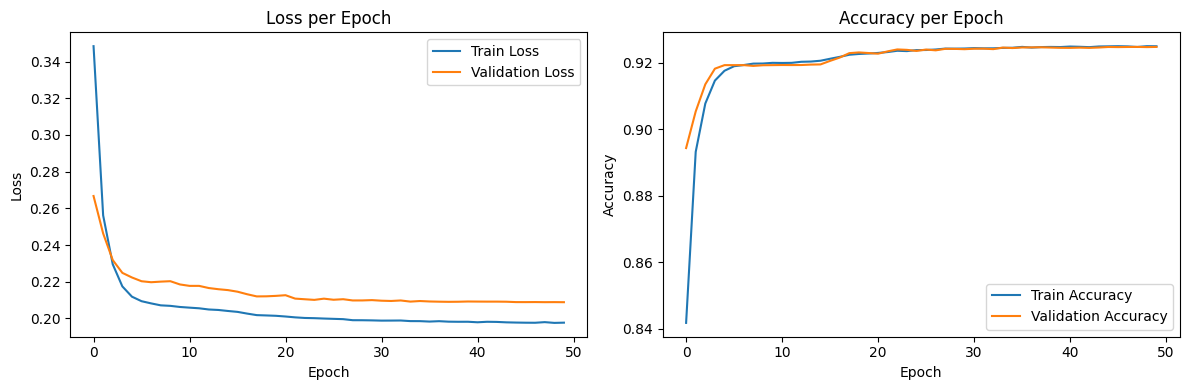

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


In [34]:
y_pred_train_ann_proba = ann_model.predict(X_train)
y_pred_test_ann_proba = ann_model.predict(X_test)

y_pred_train_ann = (y_pred_train_ann_proba > 0.5).astype(int)
y_pred_test_ann = (y_pred_test_ann_proba > 0.5).astype(int)

9833/9833 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
2042/2042 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [35]:
print('Classification Report Train:')
print(classification_report(y_train, y_pred_train_ann, digits=4))

Classification Report Train:
              precision    recall  f1-score   support

         0.0     0.8535    1.0000    0.9209    136068
         1.0     1.0000    0.8692    0.9300    178566

    accuracy                         0.9257    314634
   macro avg     0.9267    0.9346    0.9255    314634
weighted avg     0.9366    0.9257    0.9261    314634



In [36]:
print('Classification Report Test:')
print(classification_report(y_test, y_pred_test_ann, digits=4))

Classification Report Test:
              precision    recall  f1-score   support

         0.0     0.8477    1.0000    0.9176     28340
         1.0     1.0000    0.8624    0.9261     36983

    accuracy                         0.9221     65323
   macro avg     0.9239    0.9312    0.9218     65323
weighted avg     0.9339    0.9221    0.9224     65323



In [37]:
def evaluate_model(model, X_test, y_test, label="Model"):
    results = model.evaluate(X_test, y_test, verbose=0)

    loss = results[0]
    accuracy = results[1]

    print(f"{'='*45}")
    print(f"  {label} — Test Set Results")
    print(f"{'='*45}")
    print(f"  Loss     : {loss:.4f}")
    print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)")
    print()

    cm = confusion_matrix(y_test, y_pred_test_ann)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - ANN')
    plt.show()


  Cancer and Tumor Detection — Test Set Results
  Loss     : 0.2147
  Accuracy : 0.9221 (92.2%)



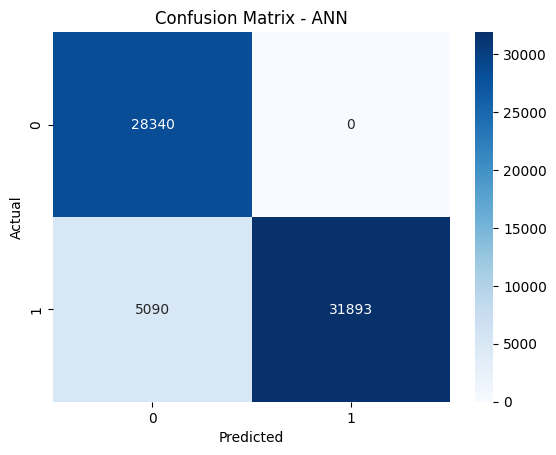

In [38]:
# Evaluate on test set

evaluate_model(ann_model, X_test, y_test, label="Cancer and Tumor Detection")


## Saving Model And Pipeline

In [39]:
ann_model.save('ann_model.keras')
print('ANN Model saved as ann_model.keras')

ANN Model saved as ann_model.keras


In [40]:
joblib.dump(final_pipeline, 'final_pipeline.pkl')
print('Preprocessing pipeline saved as final_pipeline.pkl')

Preprocessing pipeline saved as final_pipeline.pkl


In [41]:
model_config = {
    'num_columns': num_columns,
    'ordinal_categories': ordinal_categories,
    'input_dim': input_dim
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=4)

print('Model configuration saved as model_config.json')

Model configuration saved as model_config.json


In [42]:
loaded_model = keras.models.load_model('ann_model.h5')
print('Model loaded successfully')

loaded_pipeline = joblib.load('final_pipeline.pkl')
print('Pipeline loaded successfully')


with open('model_config.json', 'r') as f:
    model_config = json.load(f)
print('Model config loaded successfully')
print(f'Input dimensions: {model_config["input_dim"]}')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'ann_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)